# 🌐 Loss Surface Geometry — Hessians, Eigenvalues, and Why Curvature Dictates Convergence

**What this notebook does**

- Derives the analytic **Hessian** for two 2D test functions: a tunable anisotropic quadratic bowl and the classic Rosenbrock valley.
- Eigen-decomposes the Hessian at every point of a grid and visualizes two curvature *fields*:
  - a heatmap of the local **condition number** $\kappa(x,y) = |\lambda_{\max}| / |\lambda_{\min}|$
  - a quiver field of the local **principal curvature directions** (Hessian eigenvectors)
- Shows a controlled before/after: vanilla gradient descent on a **well-conditioned** bowl vs. the **same optimizer, same start, same learning rate** on an **ill-conditioned** bowl — isolating curvature as the only variable that changes.
- Ties the observed zig-zagging directly to the motivation for preconditioning / curvature-aware methods (Newton's method, K-FAC) covered elsewhere in this repository.

**References**

- Boyd, S., & Vandenberghe, L. (2004). *Convex Optimization*, Ch. 9 (unconstrained minimization, condition number and gradient descent convergence rate).
- Nocedal, J., & Wright, S. (2006). *Numerical Optimization*, Ch. 3 & 6 (Newton's method, quasi-Newton methods).
- Martens, J., & Grosse, R. (2015). *Optimizing Neural Networks with Kronecker-Factored Approximate Curvature (K-FAC)*.
- Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*, Ch. 4 & 8 (numerical computation, curvature, and optimization for training deep models).

This notebook is pedagogical: the implementations below are simplified for clarity and visualization; they are **not** production-ready numerical-optimization or automatic-differentiation code.

## 🔍 Conceptual Intuition

The **Hessian** $H(x,y) = \nabla^2 f(x,y)$ describes how the gradient itself changes as we move — i.e. the *local curvature* of the loss surface. Its eigenvalues $\lambda_1, \lambda_2$ tell us how sharply the surface curves along each of its (orthogonal) principal axes — the corresponding eigenvectors.

- If $\lambda_1 \approx \lambda_2$ (eigenvalues close together), the surface curves about equally in every direction — contours look like **circles**, and gradient descent marches straight at the minimum.
- If $\lambda_1 \gg \lambda_2$ (eigenvalues very different), the surface is much steeper along one axis than the other — contours become **long, narrow ellipses**.

The ratio $\kappa = |\lambda_{\max}| / |\lambda_{\min}|$ is the **condition number** of the Hessian at that point. It is not just descriptive — it directly bounds how gradient descent behaves:

- Stability requires a learning rate $\eta < 2 / \lambda_{\max}$ (set by the *steepest* direction).
- But convergence speed along the shallowest direction scales with $\eta \, \lambda_{\min}$.

So a single global step size is forced to be tiny (to stay stable where curvature is high) while making painfully slow progress where curvature is low — the textbook **zig-zag**: repeated overshoot across the steep direction and near-standstill along the shallow one. This is purely a *geometric* pathology — it happens even on a perfectly convex quadratic bowl, with an exact gradient and no stochasticity, whenever $\kappa \gg 1$.

This is the direct motivation for **curvature-aware / preconditioned** methods covered elsewhere in this repo:

- **Newton's method** (`04_Curvature_Aware_Optimizers-2`) uses the *exact* inverse Hessian $H^{-1}$ as a preconditioner, rescaling every direction to have unit effective curvature — no zig-zag, in principle a single step suffices on a quadratic.
- **K-FAC** (`03_Curvature_Aware_Optimizers-1/2_K-FAC_from_scratch.ipynb`) approximates that same idea tractably for neural networks, using Kronecker-factored blocks of the curvature matrix instead of a full, prohibitively large Hessian.

We will:
1. Define an anisotropic quadratic bowl with a *tunable* condition number, and the Rosenbrock function (whose curvature varies across the domain).
2. Compute the analytic Hessian and eigen-decompose it on a grid to visualize condition-number and curvature-direction fields.
3. Run the same vanilla GD on a well-conditioned vs. ill-conditioned bowl to see the zig-zag emerge from curvature alone.

### Step-1: Imports and Environment Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import display, Markdown

np.random.seed(42)

### Step-2: Test Functions — Tunable Quadratic Bowl and Rosenbrock

In [2]:
def f_quad(x, y, a=1.0, b=1.0):
    """Anisotropic quadratic bowl: f = 0.5*(a*x^2 + b*y^2).
    Condition number of its (constant) Hessian is exactly max(a,b)/min(a,b)."""
    return 0.5 * (a * x**2 + b * y**2)

def grad_quad(x, y, a=1.0, b=1.0):
    return np.array([a * x, b * y])

def hessian_quad(x, y, a=1.0, b=1.0):
    # constant everywhere for a quadratic
    return np.array([[a, 0.0], [0.0, b]])


def f_rosen(x, y):
    """Classic Rosenbrock 'banana' valley — curvature varies strongly across the domain."""
    return (1 - x)**2 + 100 * (y - x**2)**2

def grad_rosen(x, y):
    dfdx = -2 * (1 - x) - 400 * x * (y - x**2)
    dfdy = 200 * (y - x**2)
    return np.array([dfdx, dfdy])

def hessian_rosen(x, y):
    # analytic second derivatives of the Rosenbrock function
    d2fdx2 = 2 - 400 * y + 1200 * x**2
    d2fdxdy = -400 * x
    d2fdy2 = 200.0
    return np.array([[d2fdx2, d2fdxdy], [d2fdxdy, d2fdy2]])

### Step-3: Eigen-decomposition Helpers (Curvature & Condition Number)

In [3]:
def local_curvature(H):
    """Eigenvalues (curvatures) and eigenvectors (principal curvature directions) of a symmetric Hessian."""
    eigvals, eigvecs = np.linalg.eigh(H)  # H is symmetric -> eigh is exact and stable
    return eigvals, eigvecs

def condition_number(H, eps=1e-10):
    """kappa = |lambda_max| / |lambda_min|, guarded against near-zero curvature (saddle/flat points)."""
    eigvals = np.linalg.eigvalsh(H)
    abs_eigs = np.abs(eigvals)
    abs_eigs = np.clip(abs_eigs, eps, None)
    return abs_eigs.max() / abs_eigs.min()

### Step-4: Condition-Number Field Over the Rosenbrock Domain

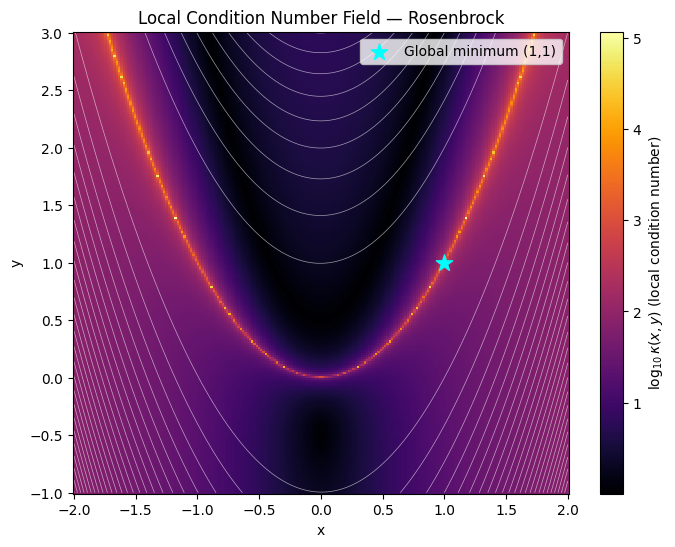

In [4]:
x = np.linspace(-2.0, 2.0, 220)
y = np.linspace(-1.0, 3.0, 220)
X, Y = np.meshgrid(x, y)
Z = f_rosen(X, Y)

kappa_field = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        H = hessian_rosen(X[i, j], Y[i, j])
        kappa_field[i, j] = condition_number(H)

fig, ax = plt.subplots(figsize=(8, 6))
# log-scale color: condition number spans several orders of magnitude across the valley
pcm = ax.pcolormesh(X, Y, np.log10(kappa_field), cmap='inferno', shading='auto')
ax.contour(X, Y, Z, levels=30, colors='white', linewidths=0.5, alpha=0.6)
ax.scatter(1, 1, c='cyan', marker='*', s=150, label='Global minimum (1,1)')
fig.colorbar(pcm, ax=ax, label=r'$\log_{10}\kappa(x,y)$ (local condition number)')
ax.set_title("Local Condition Number Field — Rosenbrock")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
plt.show()

### Step-5: Principal Curvature Directions (Eigenvector Quiver)

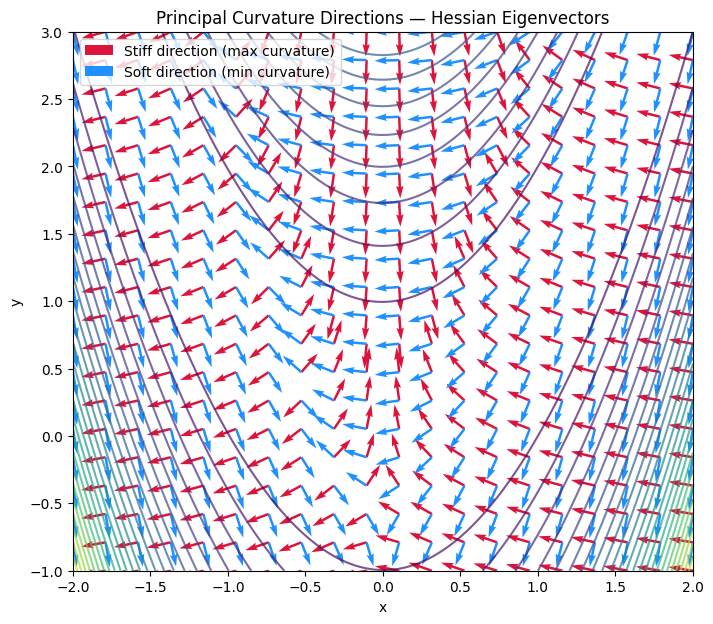

In [5]:
xs = np.linspace(-2.0, 2.0, 20)
ys = np.linspace(-1.0, 3.0, 20)
XS, YS = np.meshgrid(xs, ys)

# stiff (max-curvature) and soft (min-curvature) direction components
U_stiff, V_stiff = np.zeros_like(XS), np.zeros_like(YS)
U_soft, V_soft = np.zeros_like(XS), np.zeros_like(YS)

for i in range(XS.shape[0]):
    for j in range(XS.shape[1]):
        H = hessian_rosen(XS[i, j], YS[i, j])
        eigvals, eigvecs = local_curvature(H)
        # eigh returns eigenvalues ascending -> index 0 is softest, -1 is stiffest
        soft_dir = eigvecs[:, 0]
        stiff_dir = eigvecs[:, -1]
        U_soft[i, j], V_soft[i, j] = soft_dir
        U_stiff[i, j], V_stiff[i, j] = stiff_dir

fig, ax = plt.subplots(figsize=(8, 7))
ax.contour(X, Y, Z, levels=30, cmap='viridis', alpha=0.7)
ax.quiver(XS, YS, U_stiff, V_stiff, color='crimson', scale=25, width=0.004, label='Stiff direction (max curvature)')
ax.quiver(XS, YS, U_soft, V_soft, color='dodgerblue', scale=25, width=0.004, label='Soft direction (min curvature)')
ax.set_title("Principal Curvature Directions — Hessian Eigenvectors")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(loc='upper left')
plt.show()

### Step-6: Well-Conditioned vs. Ill-Conditioned Quadratic Bowls

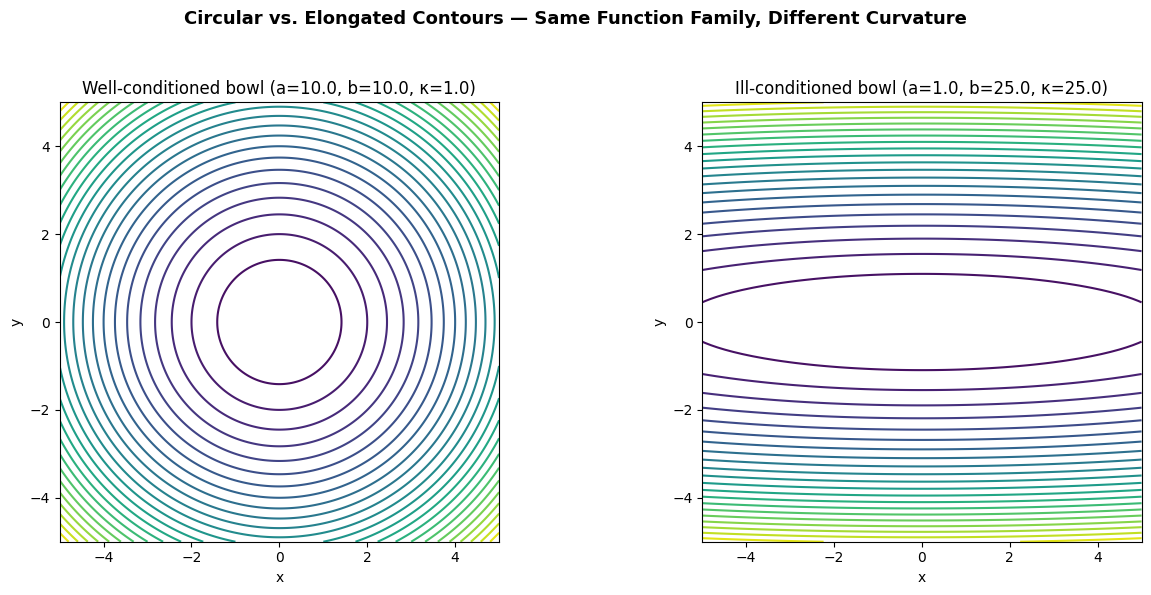

In [6]:
# The well-conditioned bowl's curvature is matched to the *steep* direction of the
# ill-conditioned bowl (both = 10) so that, later, the two runs can share one learning rate
# and the comparison isolates curvature *anisotropy* rather than curvature *scale*.
a_well, b_well = 10.0, 10.0  # kappa = 1  -> circular contours
a_ill, b_ill = 1.0, 25.0     # kappa = 25 -> elongated contours

xq = np.linspace(-5, 5, 200)
yq = np.linspace(-5, 5, 200)
XQ, YQ = np.meshgrid(xq, yq)

Z_well = f_quad(XQ, YQ, a_well, b_well)
Z_ill = f_quad(XQ, YQ, a_ill, b_ill)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].contour(XQ, YQ, Z_well, levels=25, cmap='viridis')
axes[0].set_title(f"Well-conditioned bowl (a={a_well}, b={b_well}, κ={max(a_well,b_well)/min(a_well,b_well):.1f})")
axes[0].set_xlabel("x"); axes[0].set_ylabel("y"); axes[0].set_aspect('equal')

axes[1].contour(XQ, YQ, Z_ill, levels=25, cmap='viridis')
axes[1].set_title(f"Ill-conditioned bowl (a={a_ill}, b={b_ill}, κ={max(a_ill,b_ill)/min(a_ill,b_ill):.1f})")
axes[1].set_xlabel("x"); axes[1].set_ylabel("y"); axes[1].set_aspect('equal')

plt.suptitle("Circular vs. Elongated Contours — Same Function Family, Different Curvature", fontsize=13, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

### Step-7: Vanilla Gradient Descent (Pedagogical Implementation)

In [7]:
def gradient_descent(grad_fn, start, lr=0.05, n_iter=60, **grad_kwargs):
    """Plain gradient descent. Pedagogical: no line search, no adaptivity, no momentum —
    kept minimal on purpose so that the *only* thing changing between runs below is curvature."""
    x = np.asarray(start, dtype=float).copy()
    path = [x.copy()]
    for _ in range(n_iter):
        g = grad_fn(x[0], x[1], **grad_kwargs)
        x = x - lr * g
        path.append(x.copy())
    return np.array(path)

### Step-8: Before/After — Same Optimizer, Same Start, Same LR, Only Curvature Changes

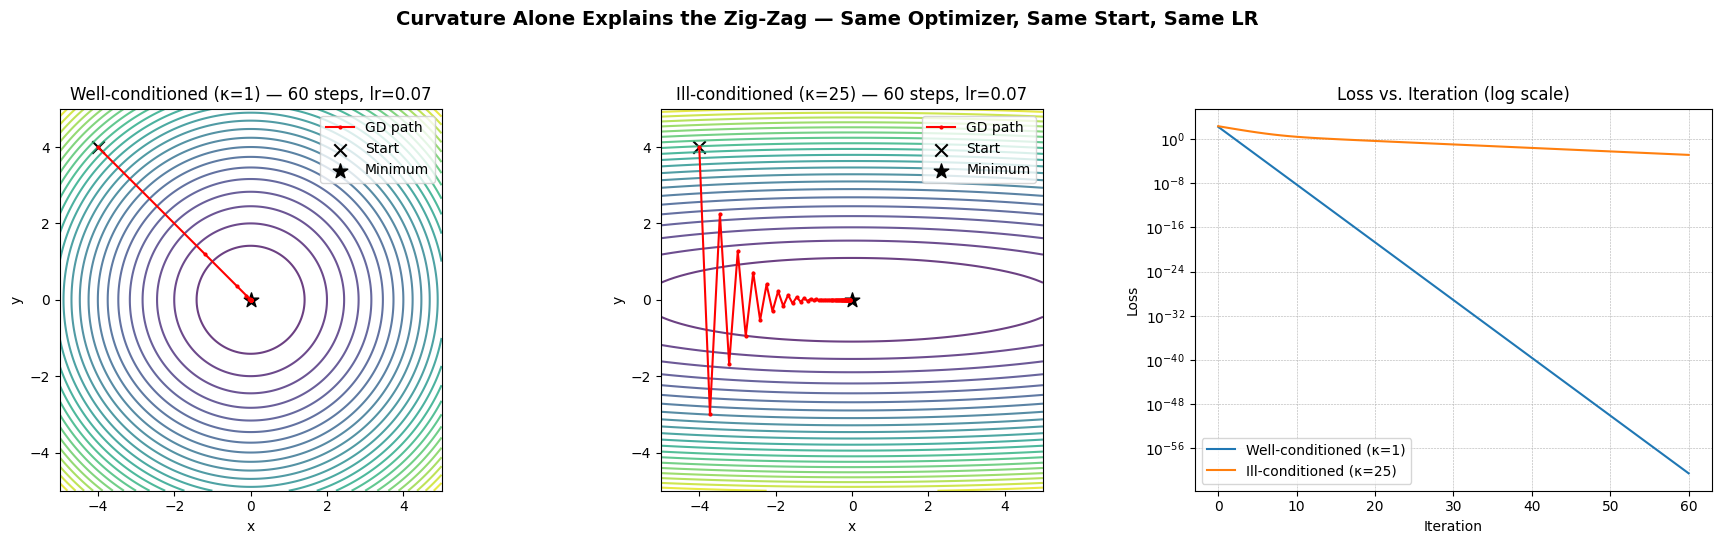

Well-conditioned: reached loss 2.88e-61 after 60 steps
Ill-conditioned:  reached loss 1.32e-03 after 60 steps


In [8]:
start = np.array([-4.0, 4.0])
lr = 0.07      # close to (but below) the stability limit of the steep direction (2/25 = 0.08);
               # deliberately shared, unchanged, across both runs below
n_iter = 60

path_well = gradient_descent(grad_quad, start, lr=lr, n_iter=n_iter, a=a_well, b=b_well)
path_ill = gradient_descent(grad_quad, start, lr=lr, n_iter=n_iter, a=a_ill, b=b_ill)

loss_well = f_quad(path_well[:, 0], path_well[:, 1], a_well, b_well)
loss_ill = f_quad(path_ill[:, 0], path_ill[:, 1], a_ill, b_ill)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

axes[0].contour(XQ, YQ, Z_well, levels=25, cmap='viridis', alpha=0.8)
axes[0].plot(path_well[:, 0], path_well[:, 1], 'r.-', lw=1.5, ms=4, label='GD path')
axes[0].scatter(*start, c='k', marker='x', s=80, label='Start')
axes[0].scatter(0, 0, c='k', marker='*', s=120, label='Minimum')
axes[0].set_title(f"Well-conditioned (κ=1) — {n_iter} steps, lr={lr}")
axes[0].set_aspect('equal'); axes[0].legend(); axes[0].set_xlabel("x"); axes[0].set_ylabel("y")

axes[1].contour(XQ, YQ, Z_ill, levels=25, cmap='viridis', alpha=0.8)
axes[1].plot(path_ill[:, 0], path_ill[:, 1], 'r.-', lw=1.5, ms=4, label='GD path')
axes[1].scatter(*start, c='k', marker='x', s=80, label='Start')
axes[1].scatter(0, 0, c='k', marker='*', s=120, label='Minimum')
axes[1].set_title(f"Ill-conditioned (κ=25) — {n_iter} steps, lr={lr}")
axes[1].set_aspect('equal'); axes[1].legend(); axes[1].set_xlabel("x"); axes[1].set_ylabel("y")

axes[2].plot(loss_well, label=f'Well-conditioned (κ=1)')
axes[2].plot(loss_ill, label=f'Ill-conditioned (κ=25)')
axes[2].set_yscale('log')
axes[2].set_title("Loss vs. Iteration (log scale)")
axes[2].set_xlabel("Iteration"); axes[2].set_ylabel("Loss"); axes[2].legend()
axes[2].grid(True, ls='--', lw=0.4)

plt.suptitle("Curvature Alone Explains the Zig-Zag — Same Optimizer, Same Start, Same LR", fontsize=14, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

print(f"Well-conditioned: reached loss {loss_well[-1]:.2e} after {n_iter} steps")
print(f"Ill-conditioned:  reached loss {loss_ill[-1]:.2e} after {n_iter} steps")

### Step-9: Interactive Explorer — Tune the Condition Number and Learning Rate

In [9]:
try:
    import ipywidgets as widgets
    from ipywidgets import interact, FloatSlider, IntSlider
except ImportError:
    !pip install ipywidgets
    import ipywidgets as widgets
    from ipywidgets import interact, FloatSlider, IntSlider

from IPython.display import clear_output

def explore_conditioning(a=1.0, b=25.0, lr=0.07, n_iter=60):
    clear_output(wait=True)
    kappa = max(a, b) / min(a, b)
    start = np.array([-4.0, 4.0])

    path = gradient_descent(grad_quad, start, lr=lr, n_iter=n_iter, a=a, b=b)
    loss = f_quad(path[:, 0], path[:, 1], a, b)

    lim = 5
    xq = np.linspace(-lim, lim, 200)
    yq = np.linspace(-lim, lim, 200)
    XQi, YQi = np.meshgrid(xq, yq)
    Zi = f_quad(XQi, YQi, a, b)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].contour(XQi, YQi, Zi, levels=25, cmap='viridis', alpha=0.85)
    axes[0].plot(path[:, 0], path[:, 1], 'r.-', lw=1.5, ms=4)
    axes[0].scatter(*start, c='k', marker='x', s=80, label='Start')
    axes[0].scatter(0, 0, c='k', marker='*', s=120, label='Minimum')
    axes[0].set_title(f"GD path (a={a:.1f}, b={b:.1f}, κ={kappa:.1f})")
    axes[0].set_aspect('equal'); axes[0].legend()

    axes[1].plot(loss)
    axes[1].set_yscale('log')
    axes[1].set_title("Loss vs. Iteration (log scale)")
    axes[1].set_xlabel("Iteration"); axes[1].set_ylabel("Loss")
    axes[1].grid(True, ls='--', lw=0.4)

    plt.tight_layout()
    plt.show()

    stability_limit = 2.0 / max(a, b)
    display(Markdown(
        f"""
        ### Current Settings
        - a = `{a:.2f}`, b = `{b:.2f}`  →  condition number κ = `{kappa:.2f}`
        - Learning rate: `{lr:.3f}`  (GD stability limit here is roughly `2/max(a,b) = {stability_limit:.3f}`)
        - Final loss after {n_iter} steps: `{loss[-1]:.3e}`
        """
    ))

interact(
    explore_conditioning,
    a=FloatSlider(value=1.0, min=0.5, max=25.0, step=0.5, description='a'),
    b=FloatSlider(value=25.0, min=0.5, max=25.0, step=0.5, description='b'),
    lr=FloatSlider(value=0.07, min=0.005, max=0.09, step=0.005, description='lr'),
    n_iter=IntSlider(value=60, min=10, max=200, step=10, description='n_iter'),
);

interactive(children=(FloatSlider(value=1.0, description='a', max=25.0, min=0.5, step=0.5), FloatSlider(value=…

## ✅ Practical Notes & Takeaways

- The condition number $\kappa = |\lambda_{\max}|/|\lambda_{\min}|$ of the Hessian is not an abstract diagnostic — it is a direct, quantitative predictor of how many gradient-descent iterations you need. Roughly, convergence rate scales like $\left(\frac{\kappa-1}{\kappa+1}\right)^2$ per step for a quadratic, so $\kappa=25$ is dramatically slower to converge than $\kappa=1$ even though both are convex bowls.
- On real loss surfaces (like Rosenbrock, or any deep network loss), the condition number is **not constant** — it varies point to point, which is why a fixed learning rate that is stable near the start can become slow or unstable elsewhere. This is exactly what the condition-number heatmap in Step-4 makes visible.
- **Diagonal preconditioners** (Adam, RMSProp, Adagrad — see `01_Basics` and `02_SOTA_Optimizers`) approximate a cheap per-parameter rescaling that partially corrects for anisotropic curvature, but only along the coordinate axes — they cannot correct curvature that is *rotated* relative to the parameter axes (off-diagonal Hessian terms), which is exactly what the eigenvector quiver in Step-5 reveals.
- **Newton's method** uses the exact $H^{-1}$ to fully equalize curvature in every direction (perfect preconditioning on a quadratic, one step to convergence) — but computing and inverting $H$ is $O(n^3)$ and infeasible for large models. See `04_Curvature_Aware_Optimizers-2`.
- **K-FAC** (`03_Curvature_Aware_Optimizers-1/2_K-FAC_from_scratch.ipynb`) is the tractable middle ground: it approximates the curvature matrix with Kronecker-factored blocks, capturing much of the off-diagonal, rotated-curvature correction that diagonal methods miss, at a fraction of Newton's cost.
- Rule of thumb when debugging slow/unstable training: if loss oscillates violently in some directions while barely moving in others, suspect ill-conditioning before suspecting a bad learning-rate schedule.

# 🧾 Summary

- The Hessian's eigenvalues quantify local curvature; their ratio (the condition number) governs how efficiently a fixed-step gradient method can descend.
- Elongated, narrow contours are the geometric signature of ill-conditioning — and they force gradient descent into the classic zig-zag: too-large steps in the steep direction, too-small steps in the shallow one.
- We isolated this effect directly: identical optimizer, identical start point, identical learning rate — only the curvature (κ) changed, and that alone explained the difference in convergence speed.
- This is the precise geometric motivation for every curvature-aware optimizer in this repository: Newton's method, quasi-Newton (BFGS/L-BFGS), and K-FAC all exist to correct for exactly the anisotropy visualized here.

---

References (quick):
- Boyd & Vandenberghe, *Convex Optimization*, Ch. 9.
- Nocedal & Wright, *Numerical Optimization*, Ch. 3 & 6.
- Martens & Grosse (2015), K-FAC.
- Goodfellow, Bengio & Courville, *Deep Learning*, Ch. 4 & 8.